In [2]:
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- load (this is the part that was missing) ---
uploaded = files.upload()   # pick Bank_Marketing_Dataset.csv
csv_name = next(name for name in uploaded if name.lower().endswith(".csv"))
df = pd.read_csv(csv_name)

# --- cleaning & preprocessing ---
df["y"] = (df["y"] == "yes").astype(int)
df = df.drop(columns=["duration"])
df["prev_contacted"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)
df = df.drop_duplicates()

X = df.drop(columns=["y"])
y = df["y"]
NUM = ["age", "balance", "day", "campaign", "pdays", "previous", "prev_contacted"]
CAT = ["job", "marital", "education", "default", "housing",
       "loan", "contact", "month", "poutcome"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Features after encoding:", preprocessor.fit_transform(X_train).shape[1])
print("Train balance:", y_train.value_counts(normalize=True).round(3).to_dict())

Saving Bank Marketing Dataset.csv to Bank Marketing Dataset (1).csv
Train rows: 36168 | Test rows: 9042
Features after encoding: 51
Train balance: {0: 0.825, 1: 0.175}


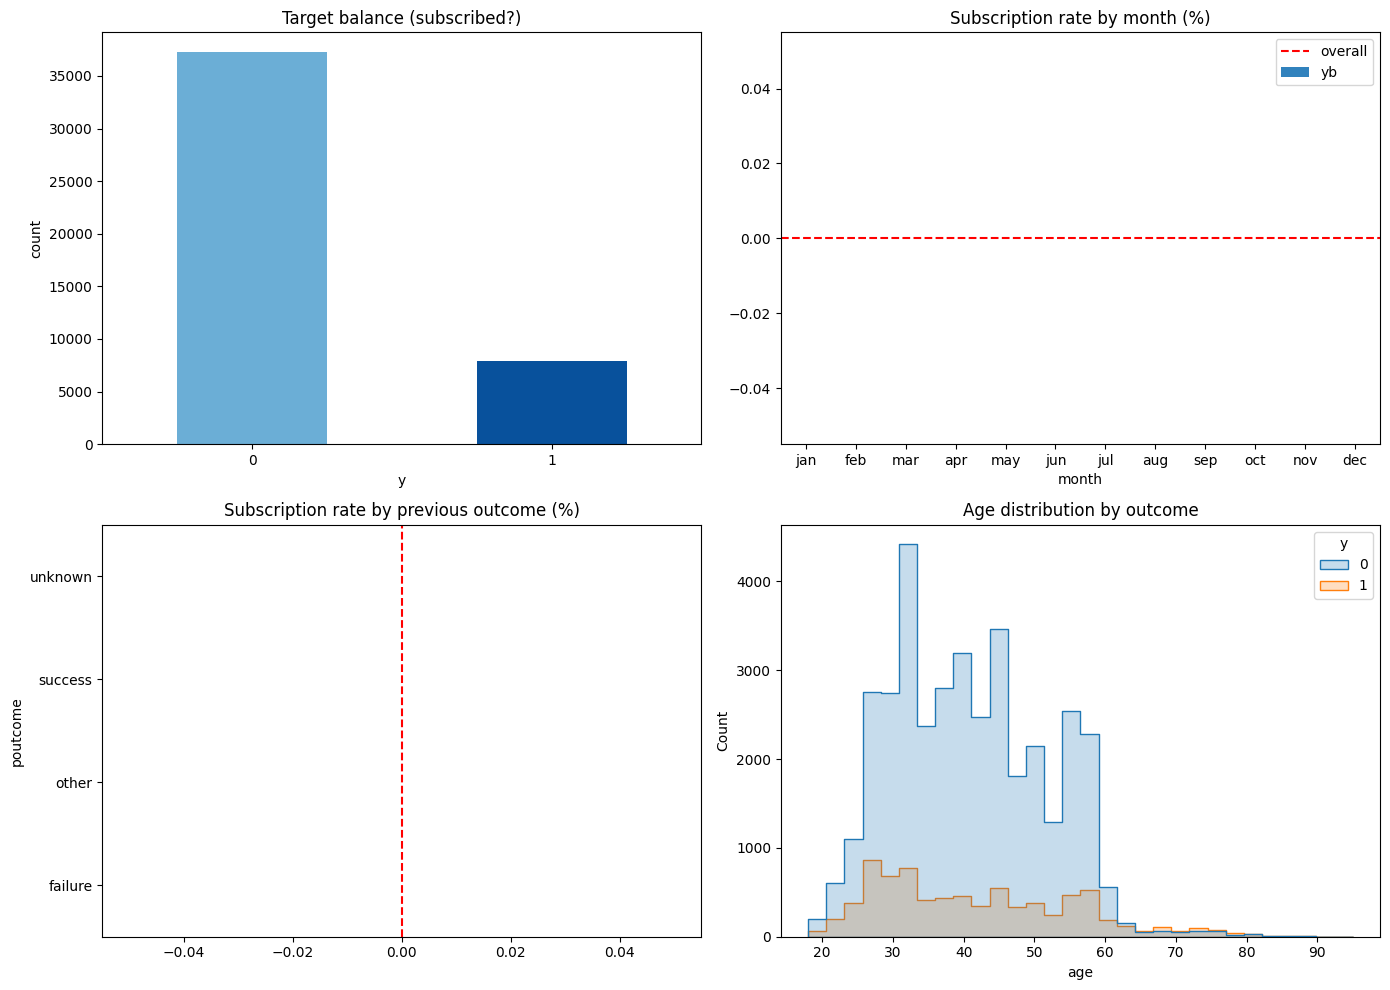

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

d = df.copy()
d["yb"] = (d["y"] == "yes").astype(int)
overall = d["yb"].mean()

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# 1. target balance
d["y"].value_counts().plot.bar(ax=ax[0,0], color=["#6baed6", "#08519c"])
ax[0,0].set_title("Target balance (subscribed?)")
ax[0,0].set_ylabel("count"); ax[0,0].tick_params(rotation=0)

# 2. subscription rate by month (ordered calendar)
order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
(d.groupby("month")["yb"].mean().reindex(order)*100).plot.bar(ax=ax[0,1], color="#3182bd")
ax[0,1].axhline(overall*100, color="red", ls="--", label="overall")
ax[0,1].set_title("Subscription rate by month (%)"); ax[0,1].legend(); ax[0,1].tick_params(rotation=0)

# 3. subscription rate by previous outcome
(d.groupby("poutcome")["yb"].mean().sort_values()*100).plot.barh(ax=ax[1,0], color="#3182bd")
ax[1,0].axvline(overall*100, color="red", ls="--")
ax[1,0].set_title("Subscription rate by previous outcome (%)")

# 4. age distribution by outcome
sns.histplot(data=d, x="age", hue="y", bins=30, ax=ax[1,1], element="step")
ax[1,1].set_title("Age distribution by outcome")

plt.tight_layout(); plt.show()

Overall subscription rate: 0.175


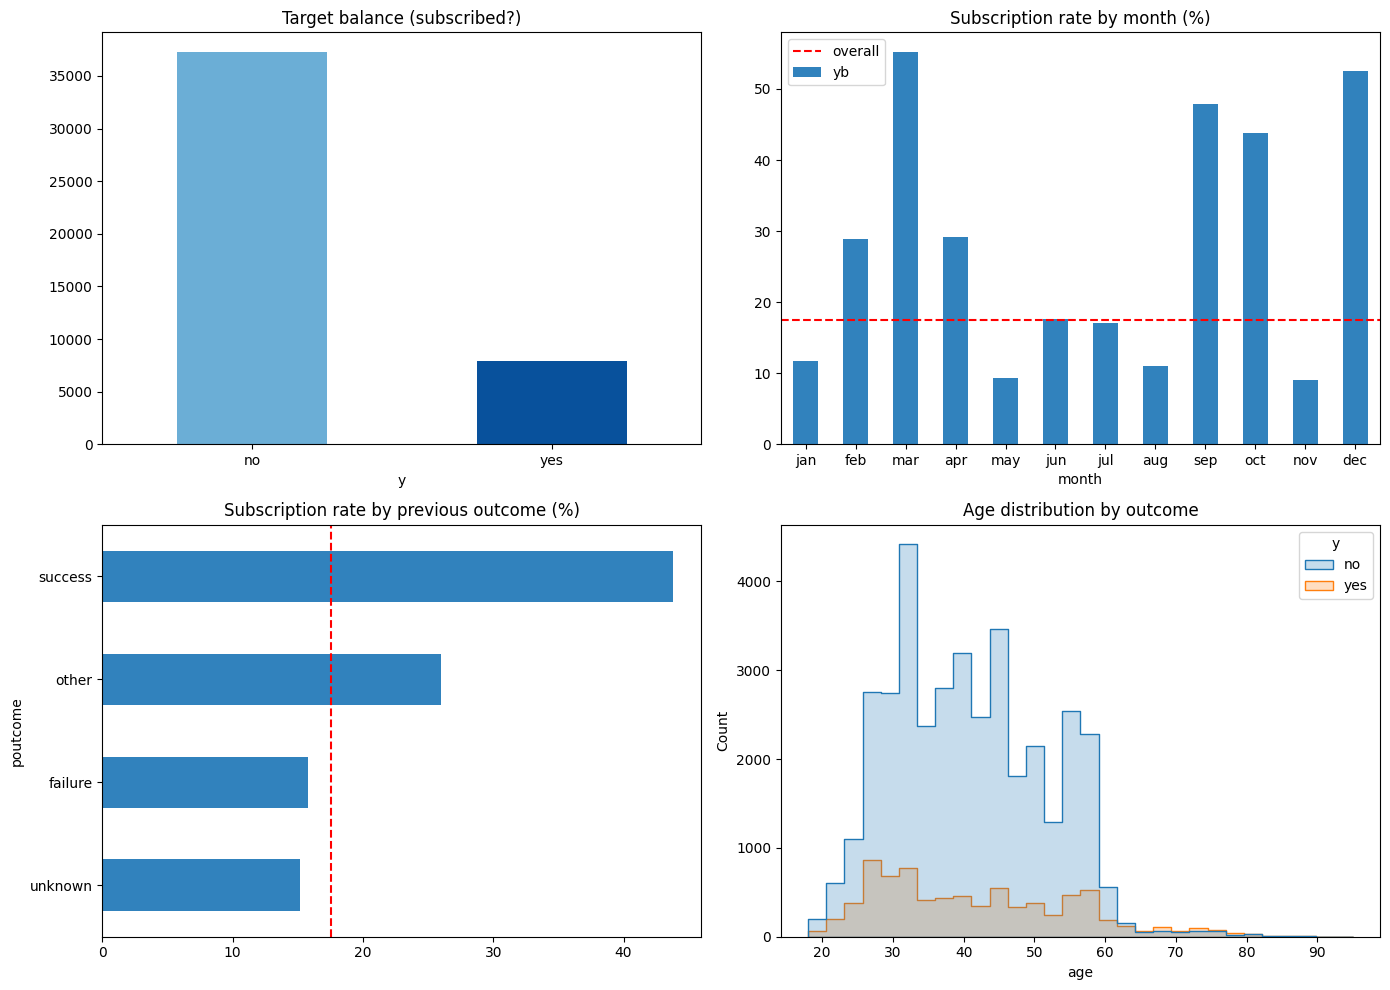

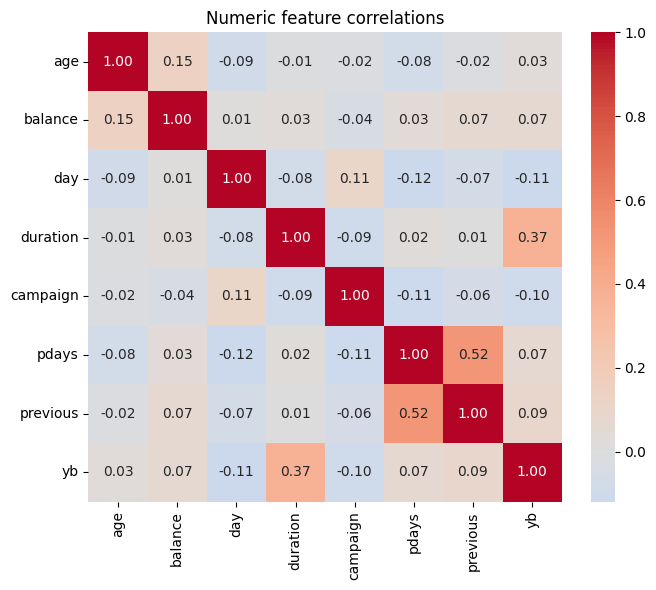


Subscription rate by job (%):
job
student          44.7
retired          37.4
unemployed       21.8
management       18.6
self-employed    18.3
unknown          16.2
technician       15.2
services         14.8
housemaid        13.5
blue-collar      13.1
admin.           12.4
entrepreneur     11.8

Subscription rate by housing (%):
housing
no     25.8
yes    12.0

Subscription rate by loan (%):
loan
no     18.5
yes     9.6

Subscription rate by contact (%):
contact
telephone    24.6
cellular     20.1
unknown       7.7

Subscription rate by education (%):
education
primary      20.2
tertiary     19.8
secondary    16.0
unknown      12.9

Subscription rate by marital (%):
marital
single      20.6
divorced    17.3
married     15.1


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# fresh raw copy for EDA (keeps duration + original yes/no)
raw = pd.read_csv(csv_name)              # csv_name comes from your upload cell
raw["yb"] = (raw["y"] == "yes").astype(int)
overall = raw["yb"].mean()
print("Overall subscription rate:", round(overall, 3))

# ---- 4-panel overview ----
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

raw["y"].value_counts().plot.bar(ax=ax[0, 0], color=["#6baed6", "#08519c"])
ax[0, 0].set_title("Target balance (subscribed?)"); ax[0, 0].tick_params(rotation=0)

order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
(raw.groupby("month")["yb"].mean().reindex(order) * 100).plot.bar(ax=ax[0, 1], color="#3182bd")
ax[0, 1].axhline(overall * 100, color="red", ls="--", label="overall")
ax[0, 1].set_title("Subscription rate by month (%)"); ax[0, 1].legend(); ax[0, 1].tick_params(rotation=0)

(raw.groupby("poutcome")["yb"].mean().sort_values() * 100).plot.barh(ax=ax[1, 0], color="#3182bd")
ax[1, 0].axvline(overall * 100, color="red", ls="--")
ax[1, 0].set_title("Subscription rate by previous outcome (%)")

sns.histplot(data=raw, x="age", hue="y", bins=30, ax=ax[1, 1], element="step")
ax[1, 1].set_title("Age distribution by outcome")

plt.tight_layout(); plt.show()

# ---- correlation heatmap ----
num_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous", "yb"]
plt.figure(figsize=(7, 6))
sns.heatmap(raw[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.tight_layout(); plt.show()

# ---- subscription rate by key categories (printed table) ----
for col in ["job", "housing", "loan", "contact", "education", "marital"]:
    rate = (raw.groupby(col)["yb"].mean() * 100).sort_values(ascending=False).round(1)
    print(f"\nSubscription rate by {col} (%):")
    print(rate.to_string())

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- reload fresh so the cell is repeatable (uses csv_name from your upload cell) ---
df = pd.read_csv(csv_name)

# base cleaning
df["y"] = (df["y"] == "yes").astype(int)
df = df.drop(columns=["duration"]).drop_duplicates()

# ---- feature engineering ----
df["prev_contacted"] = (df["pdays"] != -1).astype(int)       # fix sentinel
df["pdays"] = df["pdays"].replace(-1, 0)
df["prev_success"] = (df["poutcome"] == "success").astype(int)
df["loan_count"]   = (df["housing"] == "yes").astype(int) + (df["loan"] == "yes").astype(int)
df["neg_balance"]  = (df["balance"] < 0).astype(int)
df["age_group"]    = pd.cut(df["age"], [17, 30, 40, 50, 60, 120],
                            labels=["<=30", "31-40", "41-50", "51-60", "60+"])
high_months = ["mar", "sep", "oct", "dec", "apr", "feb"]
df["good_month"]    = df["month"].isin(high_months).astype(int)
df["many_contacts"] = (df["campaign"] >= 4).astype(int)

# ---- features / target ----
X = df.drop(columns=["y"])
y = df["y"]

NUM = ["age", "balance", "day", "campaign", "pdays", "previous",
       "prev_contacted", "prev_success", "loan_count", "neg_balance",
       "good_month", "many_contacts"]
CAT = ["job", "marital", "education", "default", "housing", "loan",
       "contact", "month", "poutcome", "age_group"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print("Total features after encoding:", preprocessor.fit_transform(X_train).shape[1])

Total features after encoding: 61


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

print(f"{'Model':22s}{'ROC-AUC':>9}{'F1':>7}{'Recall':>8}{'Prec':>7}")
for name, m in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", m)])
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    print(f"{name:22s}{roc_auc_score(y_test, proba):>9.3f}"
          f"{f1_score(y_test, pred):>7.3f}{recall_score(y_test, pred):>8.3f}"
          f"{precision_score(y_test, pred):>7.3f}")

Model                   ROC-AUC     F1  Recall   Prec
Logistic Regression       0.783  0.468   0.695  0.352
Decision Tree             0.732  0.424   0.701  0.303
Random Forest             0.776  0.442   0.402  0.491
Gradient Boosting         0.788  0.298   0.199  0.593


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# build the two shortlisted pipelines (preprocessing + model in one object)
trained = {}

trained["Logistic Regression"] = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

trained["Gradient Boosting"] = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42)),
])

# --- the training step: .fit() adjusts the model's internal parameters ---
for name, pipe in trained.items():
    pipe.fit(X_train, y_train)
    print(f"Trained: {name}  (on {X_train.shape[0]} rows)")

print("\nBoth models trained and stored in `trained` dict.")

Trained: Logistic Regression  (on 36168 rows)
Trained: Gradient Boosting  (on 36168 rows)

Both models trained and stored in `trained` dict.


In [8]:
from sklearn.metrics import roc_auc_score

for name, pipe in trained.items():
    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  pipe.predict_proba(X_test)[:, 1])
    print(f"{name:22s} train AUC={train_auc:.3f}  test AUC={test_auc:.3f}")

Logistic Regression    train AUC=0.783  test AUC=0.783
Gradient Boosting      train AUC=0.796  test AUC=0.788



========== Logistic Regression ==========
Train AUC 0.783  vs  Test AUC 0.783  (gap -0.000)
PR-AUC: 0.450
              precision    recall  f1-score   support

          no      0.918     0.728     0.812      7456
         yes      0.352     0.695     0.468      1586

    accuracy                          0.722      9042
   macro avg      0.635     0.712     0.640      9042
weighted avg      0.819     0.722     0.752      9042



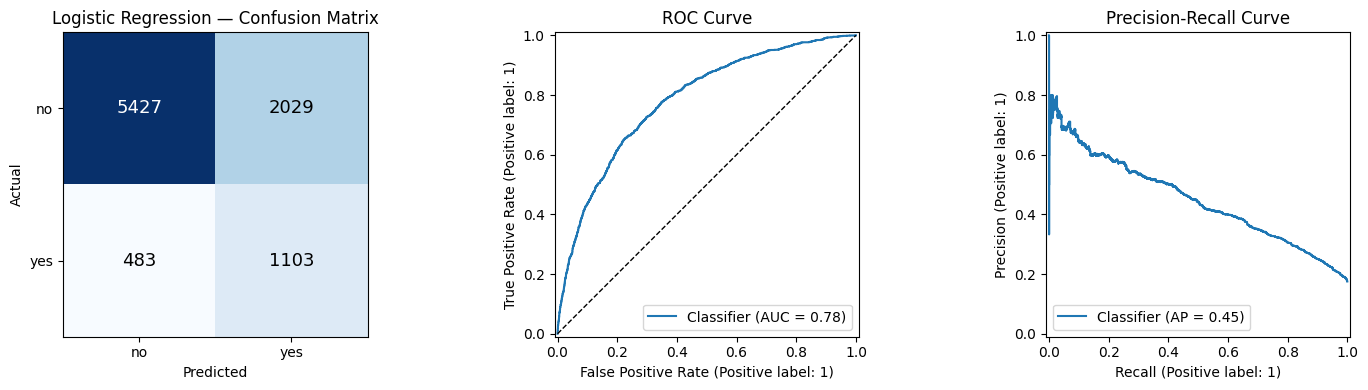


========== Gradient Boosting ==========
Train AUC 0.796  vs  Test AUC 0.788  (gap +0.008)
PR-AUC: 0.460
              precision    recall  f1-score   support

          no      0.851     0.971     0.907      7456
         yes      0.593     0.199     0.298      1586

    accuracy                          0.836      9042
   macro avg      0.722     0.585     0.602      9042
weighted avg      0.806     0.836     0.800      9042



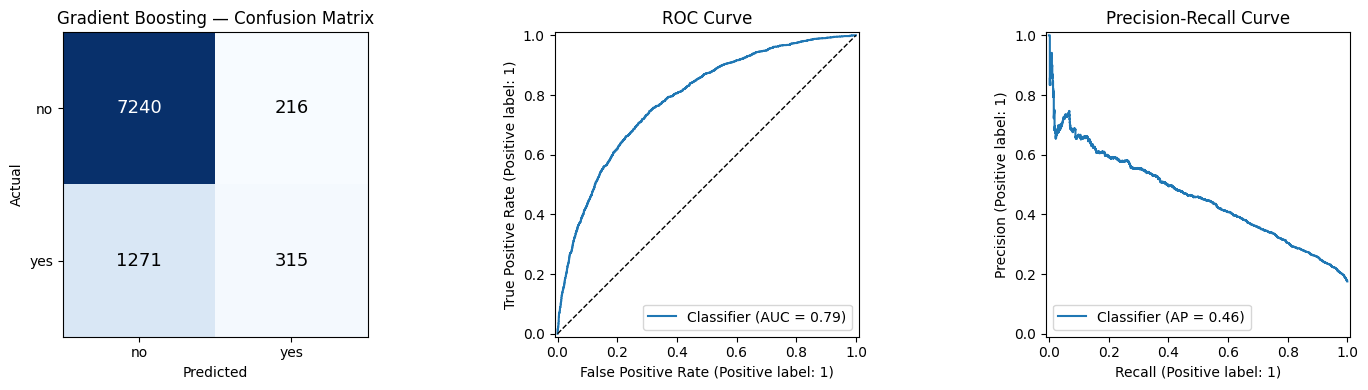

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay)

for name, pipe in trained.items():
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    train_auc = roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test, proba)

    print(f"\n========== {name} ==========")
    print(f"Train AUC {train_auc:.3f}  vs  Test AUC {test_auc:.3f}  "
          f"(gap {train_auc - test_auc:+.3f})")
    print(f"PR-AUC: {average_precision_score(y_test, proba):.3f}")
    print(classification_report(y_test, pred, target_names=["no", "yes"], digits=3))

    # confusion matrix + ROC + PR curves
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    cm = confusion_matrix(y_test, pred)
    im = ax[0].imshow(cm, cmap="Blues")
    ax[0].set_xticks([0, 1]); ax[0].set_yticks([0, 1])
    ax[0].set_xticklabels(["no", "yes"]); ax[0].set_yticklabels(["no", "yes"])
    ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
    ax[0].set_title(f"{name} — Confusion Matrix")
    for i in range(2):
        for j in range(2):
            ax[0].text(j, i, cm[i, j], ha="center", va="center",
                       color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)

    RocCurveDisplay.from_predictions(y_test, proba, ax=ax[1])
    ax[1].plot([0, 1], [0, 1], "k--", lw=1); ax[1].set_title("ROC Curve")

    PrecisionRecallDisplay.from_predictions(y_test, proba, ax=ax[2])
    ax[2].set_title("Precision-Recall Curve")

    plt.tight_layout(); plt.show()

In [10]:
import pandas as pd, numpy as np, warnings; warnings.filterwarnings("ignore")
from google.colab import files
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, recall_score, precision_score, precision_recall_curve)

# ---------- load ----------
uploaded = files.upload()                       # pick Bank_Marketing_Dataset.csv
csv_name = next(n for n in uploaded if n.lower().endswith(".csv"))
df = pd.read_csv(csv_name)

# ---------- clean + feature engineering ----------
df["y"] = (df["y"] == "yes").astype(int)
df = df.drop(columns=["duration"]).drop_duplicates()
df["prev_contacted"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)
df["prev_success"] = (df["poutcome"] == "success").astype(int)
df["loan_count"]   = (df["housing"] == "yes").astype(int) + (df["loan"] == "yes").astype(int)
df["neg_balance"]  = (df["balance"] < 0).astype(int)
df["age_group"]    = pd.cut(df["age"], [17,30,40,50,60,120],
                            labels=["<=30","31-40","41-50","51-60","60+"])
df["good_month"]    = df["month"].isin(["mar","sep","oct","dec","apr","feb"]).astype(int)
df["many_contacts"] = (df["campaign"] >= 4).astype(int)

X = df.drop(columns=["y"]); y = df["y"]
NUM = ["age","balance","day","campaign","pdays","previous","prev_contacted",
       "prev_success","loan_count","neg_balance","good_month","many_contacts"]
CAT = ["job","marital","education","default","housing","loan",
       "contact","month","poutcome","age_group"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# ---------- hyperparameter tuning ----------
pipe = Pipeline([("prep", preprocessor),
                 ("model", GradientBoostingClassifier(random_state=42))])
param_grid = {
    "model__n_estimators":  [200, 300],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth":     [3, 4],
    "model__subsample":     [0.8, 1.0],
}
search = RandomizedSearchCV(pipe, param_grid, n_iter=8, scoring="average_precision",
                            cv=3, n_jobs=-1, random_state=42)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)

best  = search.best_estimator_
proba = best.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", round(roc_auc_score(y_test, proba), 3),
      "| PR-AUC:", round(average_precision_score(y_test, proba), 3))

# ---------- threshold tuning (max F1) ----------
prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_t = thr[np.argmax(f1s[:-1])]
pred = (proba >= best_t).astype(int)
print(f"Best threshold: {best_t:.2f}")
print(f"Recall={recall_score(y_test, pred):.3f}  "
      f"Precision={precision_score(y_test, pred):.3f}  "
      f"F1={f1_score(y_test, pred):.3f}")

Saving Bank Marketing Dataset.csv to Bank Marketing Dataset (2).csv
Best params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Test ROC-AUC: 0.79 | PR-AUC: 0.462
Best threshold: 0.23
Recall=0.596  Precision=0.417  F1=0.491


In [11]:
prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2 * prec * rec / (prec + rec + 1e-9)
best_i = np.argmax(f1s[:-1])
best_t = thr[best_i]

pred = (proba >= best_t).astype(int)
print(f"Best threshold: {best_t:.2f}")
print(f"Recall={recall_score(y_test, pred):.3f}  "
      f"Precision={precision_score(y_test, pred):.3f}  "
      f"F1={f1_score(y_test, pred):.3f}")

Best threshold: 0.23
Recall=0.596  Precision=0.417  F1=0.491


In [12]:
# Option 1: smaller, faster search — change n_iter and/or grid
search = RandomizedSearchCV(pipe, param_grid, n_iter=4, scoring="average_precision", cv=3, n_jobs=-1, random_state=42)

# Option 2: HistGradientBoostingClassifier — much faster on big data
from sklearn.ensemble import HistGradientBoostingClassifier
pipe = Pipeline([("prep", preprocessor), ("model", HistGradientBoostingClassifier(random_state=42))])

In [13]:
import joblib

# 1. The SAME feature engineering used in training, as a reusable function.
def make_features(raw):
    d = raw.copy()
    if "duration" in d.columns:
        d = d.drop(columns=["duration"])
    d["prev_contacted"] = (d["pdays"] != -1).astype(int)
    d["pdays"] = d["pdays"].replace(-1, 0)
    d["prev_success"] = (d["poutcome"] == "success").astype(int)
    d["loan_count"]   = (d["housing"] == "yes").astype(int) + (d["loan"] == "yes").astype(int)
    d["neg_balance"]  = (d["balance"] < 0).astype(int)
    d["age_group"]    = pd.cut(d["age"], [17,30,40,50,60,120],
                               labels=["<=30","31-40","41-50","51-60","60+"])
    d["good_month"]    = d["month"].isin(["mar","sep","oct","dec","apr","feb"]).astype(int)
    d["many_contacts"] = (d["campaign"] >= 4).astype(int)
    return d

# 2. Bundle everything deployment needs into ONE object:
#    the fitted pipeline + the chosen threshold.
bundle = {
    "pipeline":  best,          # tuned model from stage 9
    "threshold": float(best_t), # tuned threshold from stage 9
    "features":  NUM + CAT,     # columns the pipeline expects
}
joblib.dump(bundle, "bank_model.joblib")
print("Saved bank_model.joblib")

# 3. Download it to your computer
files.download("bank_model.joblib")

Saved bank_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
def predict_new(raw_df, bundle):
    """Score raw bank client rows -> label + probability."""
    feats = make_features(raw_df)[bundle["features"]]
    proba = bundle["pipeline"].predict_proba(feats)[:, 1]
    label = (proba >= bundle["threshold"]).astype(int)
    out = raw_df.copy()
    out["subscribe_probability"] = proba.round(3)
    out["prediction"] = ["YES" if p == 1 else "NO" for p in label]
    return out

# example: score a new client (raw columns, exactly like the original CSV)
new_client = pd.DataFrame([{
    "age": 35, "job": "management", "marital": "single", "education": "tertiary",
    "default": "no", "balance": 1500, "housing": "no", "loan": "no",
    "contact": "cellular", "day": 15, "month": "mar", "duration": 0,
    "campaign": 1, "pdays": -1, "previous": 0, "poutcome": "success",
}])

print(predict_new(new_client, bundle)[["age", "job", "month",
                                       "prediction", "subscribe_probability"]])

   age         job month prediction  subscribe_probability
0   35  management   mar        YES                  0.703


In [15]:
from fastapi import FastAPI
import pandas as pd, joblib

app = FastAPI()
bundle = joblib.load("bank_model.joblib")

@app.post("/predict")
def predict(client: dict):
    df = pd.DataFrame([client])
    result = predict_new(df, bundle)   # reuse the same function + make_features
    return {
        "prediction": result["prediction"].iloc[0],
        "probability": float(result["subscribe_probability"].iloc[0]),
    }

In [16]:
import numpy as np
import pandas as pd

def psi(expected, actual, bins=10):
    qs = np.quantile(expected, np.linspace(0, 1, bins + 1))
    qs[0], qs[-1] = -np.inf, np.inf
    e = np.clip(np.histogram(expected, qs)[0] / len(expected), 1e-4, None)
    a = np.clip(np.histogram(actual,   qs)[0] / len(actual),   1e-4, None)
    return float(np.sum((a - e) * np.log(a / e)))

def drift_report(baseline_df, live_df, numeric_cols):
    rows = []
    for c in numeric_cols:
        score = psi(baseline_df[c], live_df[c])
        flag = "OK" if score < 0.1 else ("WATCH" if score < 0.2 else "DRIFT")
        rows.append({"feature": c, "psi": round(score, 3), "status": flag})
    return pd.DataFrame(rows).sort_values("psi", ascending=False)

num_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]

# --- Case 1: stable data (use the test set as stand-in "live" data) ---
print("STABLE (test set as live data):")
print(drift_report(X_train, X_test, num_cols).to_string(index=False))

# --- Case 2: simulate drift so you can see the alarm fire ---
new_data = X_test.copy()
new_data["age"]     = new_data["age"] + 8        # clients got older
new_data["balance"] = new_data["balance"] * 1.4  # and wealthier
print("\nDRIFTED (age +8, balance x1.4):")
print(drift_report(X_train, new_data, num_cols).to_string(index=False))

STABLE (test set as live data):
 feature   psi status
 balance 0.002     OK
     age 0.001     OK
     day 0.001     OK
campaign 0.001     OK
   pdays 0.000     OK
previous 0.000     OK

DRIFTED (age +8, balance x1.4):
 feature   psi status
     age 0.941  DRIFT
 balance 0.064     OK
     day 0.001     OK
campaign 0.001     OK
   pdays 0.000     OK
previous 0.000     OK


In [17]:
import pandas as pd

# rebuild a RAW test split that lines up with y_test (same steps, same seed)
raw_all = pd.read_csv(csv_name)
raw_all["y"] = (raw_all["y"] == "yes").astype(int)
raw_all = raw_all.drop_duplicates()          # same as training (drops the 1 dup)

from sklearn.model_selection import train_test_split
raw_X = raw_all.drop(columns=["y"])          # keep ORIGINAL columns (raw)
raw_y = raw_all["y"]
_, new_X_raw, _, true_labels = train_test_split(
    raw_X, raw_y, test_size=0.2, stratify=raw_y, random_state=42)

print("new_X_raw:", new_X_raw.shape, "| true_labels:", true_labels.shape)
print(new_X_raw.columns.tolist())   # should include the raw columns make_features needs

new_X_raw: (9043, 16) | true_labels: (9043,)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']


In [18]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

def log_performance(model_bundle, new_X_raw, true_labels, baseline_f1=0.49):
    feats = make_features(new_X_raw)[model_bundle["features"]]
    proba = model_bundle["pipeline"].predict_proba(feats)[:, 1]
    pred  = (proba >= model_bundle["threshold"]).astype(int)
    metrics = {
        "recall":    round(recall_score(true_labels, pred), 3),
        "precision": round(precision_score(true_labels, pred), 3),
        "f1":        round(f1_score(true_labels, pred), 3),
        "auc":       round(roc_auc_score(true_labels, proba), 3),
        "yes_rate":  round(pred.mean(), 3),
    }
    metrics["retrain_needed"] = metrics["f1"] < baseline_f1 - 0.05
    return metrics

print(log_performance(bundle, new_X_raw, true_labels))

{'recall': 0.596, 'precision': 0.417, 'f1': 0.491, 'auc': np.float64(0.79), 'yes_rate': np.float64(0.251), 'retrain_needed': False}
